# QED-C Application-Oriented Benchmarks - IQM
The notebook demonstrates problem generation, execution, and analysis of one of the many supported application-oriented benchmarks on IQM.

Configure and run the cell below with the desired execution settings, then proceed to run the remaining cells.

In [1]:
min_qubits=2
max_qubits=2
skip_qubits=1
max_circuits=1
num_shots=1000

In [2]:
# QED-C
from bernstein_vazirani import bv_benchmark
from _common import metrics
from _common.qiskit import execute as ex

# Qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit import transpile

# IQM
from iqm.qiskit_iqm import IQMProvider

## Part 1: Problem Generation

Utilizing the new **_get_circuits_** flag in the architecture, we can supress execution and obtain only the problem generation components of interest.

The code below grabs the Bernstein-Vazirani Method 1 circuits and any metadata associated with them.

In [3]:
circuits, metadata = bv_benchmark.run(
    min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
    max_circuits=max_circuits, num_shots=num_shots, method=1, get_circuits=True
)

print(f"\nCircuits:\n{circuits}")
print(f"\nMetadata: \n{metadata}")

Bernstein-Vazirani (1) Benchmark Program - Qiskit
... execution starting at Apr 22, 2026 17:20:18 UTC
************
Creating [1] circuits with num_qubits = 3
************
Returning circuits and circuit information

Circuits:
{'3': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x14311d610>}}

Metadata: 
{'subtitle': 'Device = qasm_simulator', '3': {'1': {'create_time': 0.021435022354125977}}}


### The Circuits and Metadata
Note the format of the outputs:
- **circuits**: dict[str, dict[str, QuantumCircuit]] 
- **metadata**: dict[str, dict[str, dict[str, float]] | str]

Where 
1. The **first dictionary's key** represents the **number of qubits** for the group. In _metadata_, it may also serve as the subtitle.
2. The **second dictionary's key** represents the **unique identifier** for a circuit in the group. This may be a secret string for Bernstein-Vazirani, theta value for Phase-Estimation, and so on. Benchmark specific documentation can be found in our repository.
3. The **third dictionary's key** represents the **metric being stored** in _metadata_. (There is no third dictionary in _circuits_).

## Part 2: Execution

Now that we have the Qiskit circuits, we are free to run them using any execution framework that supports Qiskit!

### Preprocessing and Additional Metrics
We first convert the _circuits_ dictionary into a flat list; additionally, we choose to compute additional metrics and store them in the metrics module.

In [4]:
# Remove the subtitle key for iterating purposes.
metadata.pop("subtitle", None)

# Copy any metadata from creation (i.e. create_time). This can be excluded if it's not of interest.
metrics.circuit_metrics = metadata

# Create a flat list of circuits.
circuit_identifiers = []
flat_circuits = []
for num_qubits in circuits.keys():
    for circuit_id in circuits[num_qubits].keys():
        circuit_identifiers.append((num_qubits, circuit_id))
        flat_circuits.append(circuits[num_qubits][circuit_id])

        # Optionally compute additional circuit properties (depth, etc.) and store to metrics.
        ex.compute_and_store_circuit_info(
            circuits[num_qubits][circuit_id],
            str(num_qubits),
            str(circuit_id),
            do_transpile_metrics=True,
            use_normalized_depth=True,
        )

print(f"Flat Circuits: \n{flat_circuits}\n")
print(f"Additional Metrics: \n{metrics.circuit_metrics}")

Flat Circuits: 

Additional Metrics: 
{'3': {'1': {'create_time': 0.021435022354125977, 'depth': 6, 'size': 11, 'xi': 0.1111111111111111, 'n2q': 1, 'tr_depth': 6, 'tr_size': 13, 'tr_xi': 0.09090909090909091, 'tr_n2q': 1}}}


## Running Circuits

We execute the flat circuits on IQM. 

Configure the cell below with the target quantum computer and your IQM Resonance Token. 

In [5]:
iqm_server_url = "https://resonance.meetiqm.com"
quantum_computer = "sirius"
IQM_Token = "<IQM Resonance TOKEN>"

In [6]:
provider = IQMProvider(iqm_server_url, quantum_computer=quantum_computer, token=IQM_Token)
backend = provider.get_backend()

transpiled_circuit = transpile(flat_circuits, backend=backend)
job = backend.run(transpiled_circuit, shots=num_shots)

In [7]:
result = job.result()
print(result.get_counts())

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

{'01': 914, '00': 75, '11': 10, '10': 1}


## Part 3: Analysis and Results
After executing the circuits, we can use the counts to compute the fidelities, store them, and plot the results.

### Computing Fidelities
The code below uses the counts from above and stores them in the metrics module, which can then be used to create plots. 

In [8]:
class CountsWrapper:
        """
        A wrapper class to enable support with QED-C's method to analyze results.
        """

        def __init__(self, counts: dict[str, int]):
            self.counts = counts

        def get_counts(self, _):
            return self.counts
            
# Iterate over each submitted circuit using the circuit identifiers:
for curr_idx, (num_qubits, circuit_id) in enumerate(circuit_identifiers):
    # Wrap the counts
    counts = result.get_counts(curr_idx)
    result_obj = CountsWrapper(counts)
    
    # Compute the fidelity
    _, fidelity = bv_benchmark.analyze_and_print_result(
        None, result_obj, int(num_qubits), num_shots, s_int=int(circuit_id), 
    )
    
    # Store the fidelity.
    metrics.store_metric(num_qubits, circuit_id, "fidelity", fidelity)

### Visualization

Now that the fidelities are stored, we can use the metrics module to create plots. 

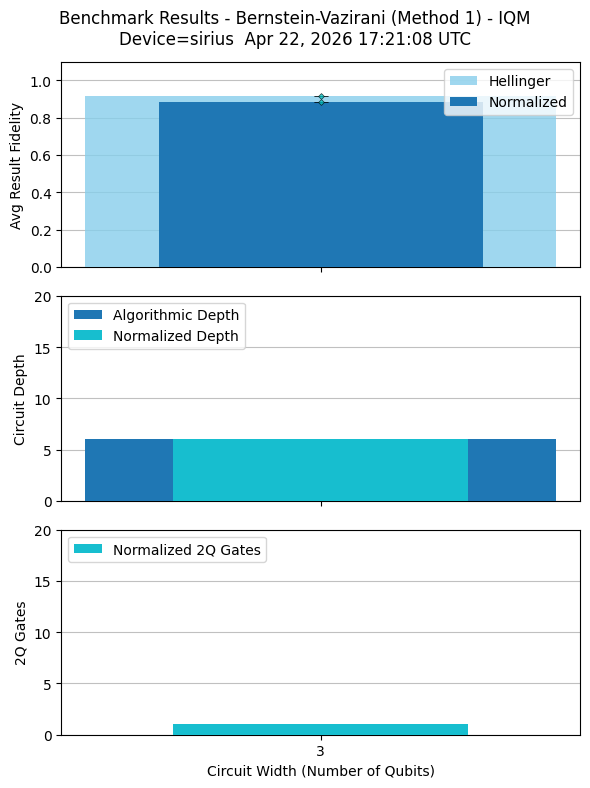

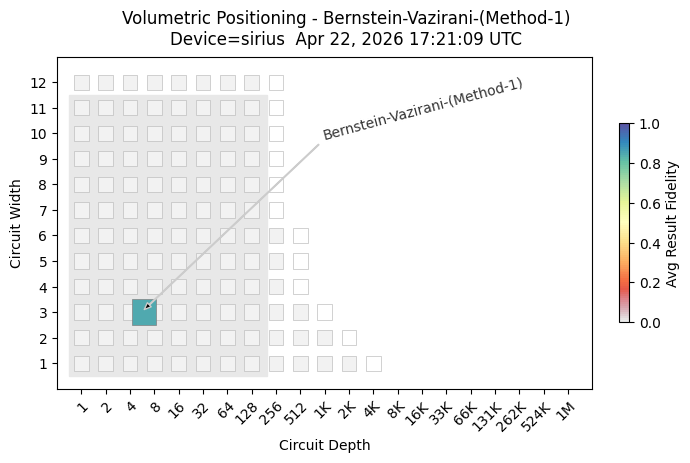

In [9]:
# Compute statistics for metrics.
metrics.aggregate_metrics()

# Set information for plot titles.
benchmark_name = "Bernstein-Vazirani"
provider_name = "IQM"
device_name = quantum_computer

# Set plot titles.
benchmark_title = f"{benchmark_name} (Method 1)"
subtitle = f"Benchmark Results - {benchmark_title} - {provider_name}"
metrics.circuit_metrics["subtitle"] = f"device = {device_name}"

# Determine which metrics to plot.
filters = ["fidelity", "hf_fidelity", "depth", "2q", "vbplot"]

# Plot the metrics.
metrics.plot_metrics(subtitle, filters=filters)

Number of Qubits: 3


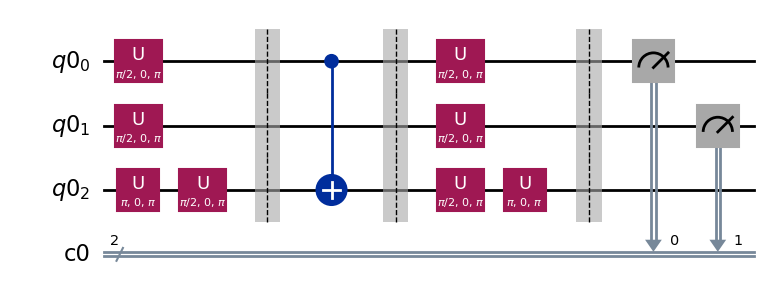

In [10]:
# Visualize the first circuit for each qubit size.
for num_qubits in circuits.keys():
    for circuit_id in circuits[num_qubits].keys():
        qc = circuits[num_qubits][circuit_id]
        print(f"Number of Qubits: {num_qubits}")
        display(qc.draw(output='mpl'))
        break